# EDA for Insurance Cost Predictor

## Key Findings
- Smokers pay ~4x more on average ($32,050 vs $8,434)
- The charge distributions are near-disjoint — smokers cluster between $20k–$50k, non-smokers under $15k
- The smoker KDE shows a bimodal shape (two peaks ~$20k and ~$40k), likely driven by BMI
- These findings justify the Block 2 stratified pipeline: route predictions through a smoker classifier first, then to separate subgroup regressors

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_theme(style="whitegrid")

# Load data
# Note: Since the notebook is in the 'exploration' folder, we use '../data/insurance.csv'
df = pd.read_csv('../data/insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [2]:
print("Dataset Shape:", df.shape)

print("\nData Types:")
print(df.dtypes)

print("\nNull Counts:")
print(df.isnull().sum())

Dataset Shape: (1338, 7)

Data Types:
age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

Null Counts:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [3]:
summary_stats = df.groupby('smoker')['charges'].agg(['mean', 'median', 'std'])
print("Summary Statistics of Charges by Smoker Status:")
summary_stats

Summary Statistics of Charges by Smoker Status:


,mean,median,std
smoker,,,
no,8434.268298,7345.40530,5993.781819
yes,32050.231832,34456.34845,11541.547176


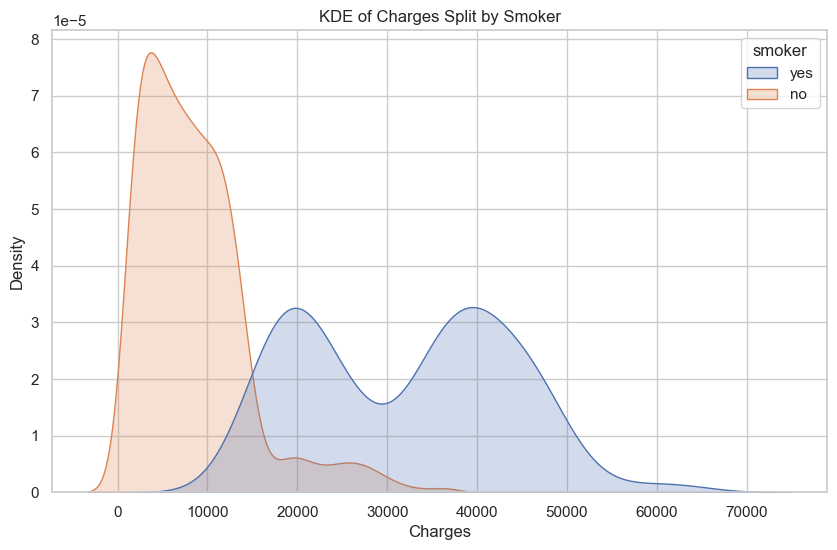

In [4]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='charges', hue='smoker', fill=True, common_norm=False)
plt.title('KDE of Charges Split by Smoker')
plt.xlabel('Charges')
plt.ylabel('Density')
plt.savefig('kde_charges_by_smoker.png', bbox_inches='tight')
plt.show()

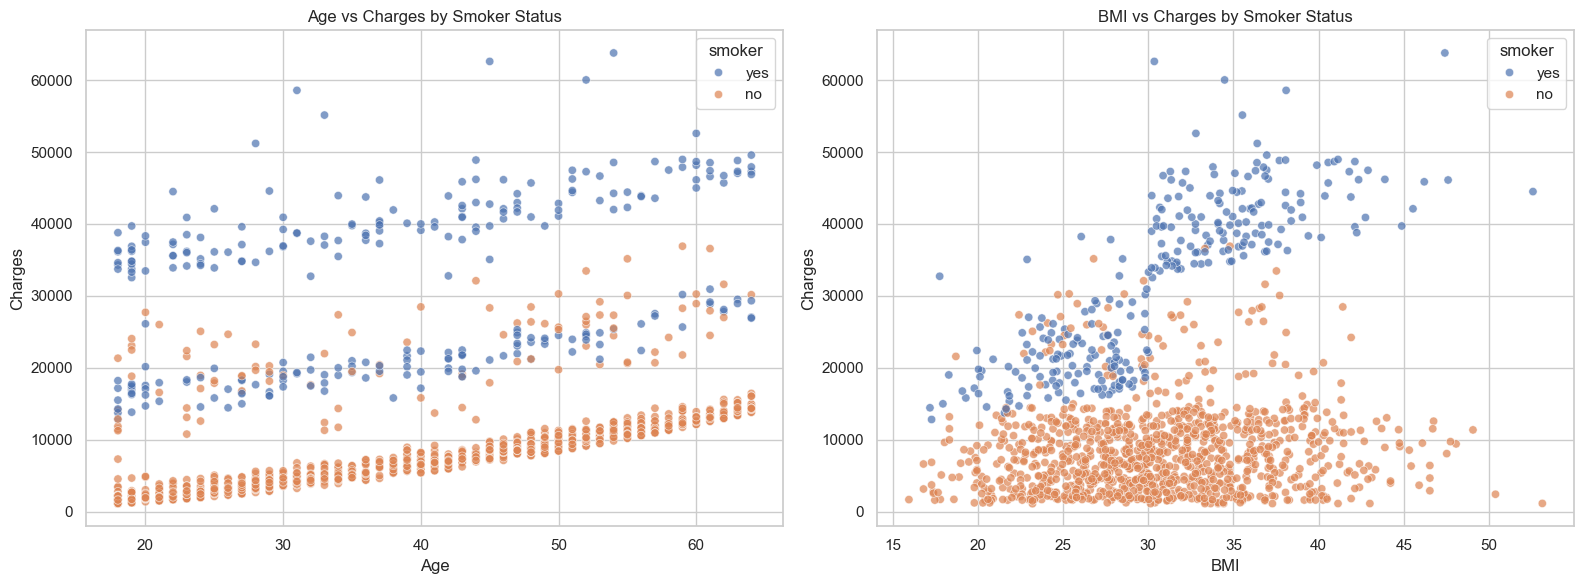

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(data=df, x='age', y='charges', hue='smoker', alpha=0.7, ax=axes[0])
axes[0].set_title('Age vs Charges by Smoker Status')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Charges')

sns.scatterplot(data=df, x='bmi', y='charges', hue='smoker', alpha=0.7, ax=axes[1])
axes[1].set_title('BMI vs Charges by Smoker Status')
axes[1].set_xlabel('BMI')
axes[1].set_ylabel('Charges')

plt.tight_layout()
plt.savefig('scatter_age_bmi_charges.png', bbox_inches='tight')
plt.show()